# Percobaan 3

Percobaan ini bertujuan untuk melakukan klasifikasi citra serat kayu Nantu, Palapi, dan Uru menggunakan fitur tekstur Gray Level Co-occurrence Matrix (GLCM). Tahapan yang dilakukan meliputi pengumpulan data, augmentasi, preprocessing, ekstraksi fitur, seleksi fitur, normalisasi, pelatihan model, dan evaluasi performa klasifikasi menggunakan Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Berbeda dengan percobaan sebelumnya, pada percobaan ini dilakukan optimasi terhadap proses klasifikasi dengan memperhatikan distribusi fitur dan parameter model. Fokus utama penelitian adalah mengukur seberapa baik fitur tekstur GLCM mampu membedakan karakteristik masing-masing jenis kayu.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Load Data

Dataset terdiri dari citra serat kayu Nantu, Palapi, dan Uru yang disimpan dalam struktur folder berdasarkan kelas. Setiap citra akan dibaca dan disimpan ke dalam array untuk diproses pada tahap berikutnya.

Kualitas data sangat mempengaruhi hasil klasifikasi. Apabila terdapat variasi pencahayaan, fokus, atau orientasi serat yang terlalu besar, maka nilai fitur tekstur yang dihasilkan dapat menjadi kurang konsisten.

In [2]:
data = []
labels = []
file_name = []
dataset_dir = "Dataset" # Gunakan nama folder dataset yang benar

if os.path.exists(dataset_dir):
    for sub_folder in os.listdir(dataset_dir):
        sub_folder_path = os.path.join(dataset_dir, sub_folder)
        if not os.path.isdir(sub_folder_path):
            continue
            
        sub_folder_files = os.listdir(sub_folder_path)
        for i, filename in enumerate(sub_folder_files):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)
            
            # Pastikan gambar berhasil dibaca (bukan file korup atau tipe file salah)
            if img is not None:
                # Resize ke ukuran standar (opsional tapi sangat disarankan agar np.array tidak error)
                img = cv.resize(img, (128, 128))
                
                img = img.astype(np.uint8)
                img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                
                data.append(img)
                labels.append(sub_folder)
                file_name.append(filename)
            else:
                print(f"Warning: Gagal membaca gambar {img_path}")

    data = np.array(data)
    labels = np.array(labels)
else:
    print(f"Direktori {dataset_dir} tidak ditemukan!")


## Data Augmentation

Augmentasi dilakukan untuk meningkatkan jumlah data pelatihan dan memperkaya variasi pola tekstur yang dipelajari model. Teknik augmentasi dapat membantu mengurangi risiko overfitting, terutama ketika jumlah citra asli relatif terbatas.

Namun demikian, augmentasi yang berlebihan juga dapat menghasilkan sampel yang terlalu mirip dengan citra asli sehingga tidak selalu memberikan peningkatan performa yang signifikan.

In [3]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img = data[i]
    label = labels[i]
    fname = file_name[i]
    
    # Citra Asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)
    
    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)
    data_augmented.append(img_flip_h)
    labels_augmented.append(label)
    file_name_augmented.append('flip_h_' + fname)
    
    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)
    data_augmented.append(img_flip_v)
    labels_augmented.append(label)
    file_name_augmented.append('flip_v_' + fname)
    
    # 3. Blur (Gaussian)
    img_blur = cv.GaussianBlur(img, (5, 5), 0)
    data_augmented.append(img_blur)
    labels_augmented.append(label)
    file_name_augmented.append('blur_' + fname)

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)


In [4]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  315
Data setelah augmentasi:  1260


## Preprocessing

Tahap preprocessing terdiri dari resize, konversi grayscale, median filtering, dan histogram equalization.

Tahapan ini dipilih untuk mempertahankan informasi tekstur sambil mengurangi noise dan meningkatkan kontras citra. Histogram Equalization membantu memperjelas pola serat kayu yang mungkin sulit dibedakan pada citra asli.

Kelebihan pendekatan ini adalah prosesnya sederhana dan relatif cepat. Namun, penggunaan grayscale menyebabkan informasi warna dihilangkan sehingga klasifikasi hanya bergantung pada tekstur. Jika warna kayu memiliki karakteristik yang berbeda antar kelas, informasi tersebut tidak dimanfaatkan oleh model.

In [5]:
def resize_img(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

def grayscale_filter(image):
    # Cek jika gambar sudah grayscale (hanya memiliki 2 dimensi)
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def median_filter(image, kernel_size=3):
    return cv.medianBlur(image, kernel_size)

def histogram_equalization(image):
    return cv.equalizeHist(image)

def preprocess_image(image, target_size=(128, 128)):
    """
    Pipeline Preprocessing:
    1. Resize
    2. Grayscale
    3. Median Filter
    4. Histogram Equalization
    """
    img = resize_img(image, target_size)
    img = grayscale_filter(img)
    img = median_filter(img, kernel_size=3)
    img = histogram_equalization(img)
    return img

# Terapkan pipeline preprocessing ke seluruh data_augmented
# Uncomment baris di bawah ini jika ingin langsung memproses data
# preprocessed_data = np.array([preprocess_image(img) for img in data_augmented])


In [6]:
# Terapkan pipeline preprocessing ke seluruh data_augmented
print("Memulai preprocessing pada data...")
data_preprocessed = np.array([preprocess_image(img) for img in data_augmented])

print(f"Preprocessing selesai!")
print(f"Total data yang diproses: {len(data_preprocessed)}")
print(f"Bentuk data baru (shape): {data_preprocessed.shape}")


Memulai preprocessing pada data...
Preprocessing selesai!
Total data yang diproses: 1260
Bentuk data baru (shape): (1260, 128, 128)


## Feature Extraction

Ekstraksi fitur dilakukan menggunakan Gray Level Co-occurrence Matrix (GLCM). Metode ini dipilih karena mampu merepresentasikan karakteristik tekstur melalui hubungan spasial antar piksel.

Fitur yang digunakan meliputi Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation pada beberapa orientasi sudut.

Kelebihan GLCM adalah kemampuannya menggambarkan tekstur secara kuantitatif. Namun, performanya sangat dipengaruhi oleh parameter seperti jarak piksel (distance), sudut (angle), dan kualitas preprocessing yang digunakan.

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm_matrix = graycomatrix(
    image,
    distances=[1,2,3],
    angles=angles,
    levels=256,
    symmetric=True,
    normed=True
)

    return glcm_matrix

In [8]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [9]:
for i in range(len(data_preprocessed)):
    data_preprocessed[i] = data_preprocessed[i].astype(np.uint8)

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data_preprocessed)):
    D0 = glcm(data_preprocessed[i], 0)
    D45 = glcm(data_preprocessed[i], 45)
    D90 = glcm(data_preprocessed[i], 90)
    D135 = glcm(data_preprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks GLCM untuk setiap sudut! ---")

--- Sukses membuat matriks GLCM untuk setiap sudut! ---


In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(data_preprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(data_preprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(data_preprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(data_preprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(data_preprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print("--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---")

--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---


## Penyimpanan Hasil Ekstraksi

Seluruh fitur hasil ekstraksi disimpan dalam format CSV untuk mempermudah proses analisis dan pelatihan model.

Penyimpanan fitur dalam bentuk tabel memungkinkan eksperimen dilakukan berulang kali tanpa harus menjalankan proses ekstraksi GLCM dari awal, sehingga waktu komputasi menjadi lebih efisien.

In [11]:
dataTable = {
    'Filename': file_name_augmented,
    'Label': labels_augmented,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,nantu_train (1).jpg,Nantu,1489.946666,2017.841404,1155.425381,2015.510881,0.253483,0.170573,0.298058,0.166712,...,0.002253,0.001140,0.042174,0.034006,0.047463,0.033767,0.863627,0.815113,0.894284,0.815309
1,flip_h_nantu_train (1).jpg,Nantu,1489.946666,2015.510881,1155.425381,2017.841404,0.253483,0.166712,0.298058,0.170573,...,0.002253,0.001156,0.042174,0.033767,0.047463,0.034006,0.863627,0.815309,0.894284,0.815113
2,flip_v_nantu_train (1).jpg,Nantu,1489.946666,2015.510881,1155.425381,2017.841404,0.253483,0.166712,0.298058,0.170573,...,0.002253,0.001156,0.042174,0.033767,0.047463,0.034006,0.863627,0.815309,0.894284,0.815113
3,blur_nantu_train (1).jpg,Nantu,432.876784,728.773762,413.886134,710.101246,0.271073,0.225744,0.273788,0.215680,...,0.002688,0.001974,0.051222,0.045349,0.051842,0.044429,0.960405,0.933227,0.962092,0.934927
4,nantu_train (10).jpg,Nantu,616.308317,1432.778722,1206.236774,1472.848844,0.358082,0.202858,0.278820,0.199686,...,0.003344,0.002429,0.069916,0.049723,0.057826,0.049290,0.943391,0.868009,0.889032,0.864311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,blur_uru_train (98).jpg,Uru,34.070189,97.578151,72.534633,94.210366,0.375397,0.266051,0.334127,0.288400,...,0.001379,0.001146,0.041517,0.032623,0.037137,0.033857,0.996835,0.990890,0.993250,0.991204
1256,uru_train (99).jpg,Uru,325.399237,385.625395,156.849840,387.990328,0.261441,0.186874,0.355558,0.193428,...,0.001259,0.000572,0.028177,0.023748,0.035479,0.023923,0.969764,0.964048,0.985441,0.963825
1257,flip_h_uru_train (99).jpg,Uru,325.399237,387.990328,156.849840,385.625395,0.261441,0.193428,0.355558,0.186874,...,0.001259,0.000564,0.028177,0.023923,0.035479,0.023748,0.969764,0.963825,0.985441,0.964048
1258,flip_v_uru_train (99).jpg,Uru,325.399237,387.990328,156.849840,385.625395,0.261441,0.193428,0.355558,0.186874,...,0.001259,0.000564,0.028177,0.023923,0.035479,0.023748,0.969764,0.963825,0.985441,0.964048


## Feature Selection

Feature Selection dilakukan untuk mengurangi redundansi antar fitur dan menghilangkan fitur yang memiliki korelasi sangat tinggi.

Pendekatan ini bertujuan mengurangi kompleksitas model dan potensi overfitting. Namun, terdapat risiko bahwa beberapa fitur yang sebenarnya masih memiliki informasi penting ikut terhapus apabila nilai threshold korelasi ditetapkan terlalu rendah.

Hal ini dapat berdampak berbeda pada setiap algoritma. Random Forest umumnya lebih toleran terhadap fitur yang banyak, sedangkan SVM dan KNN dapat menjadi lebih sensitif terhadap proses seleksi fitur.

Jumlah fitur sebelum seleksi: 28
Jumlah fitur setelah seleksi: 9


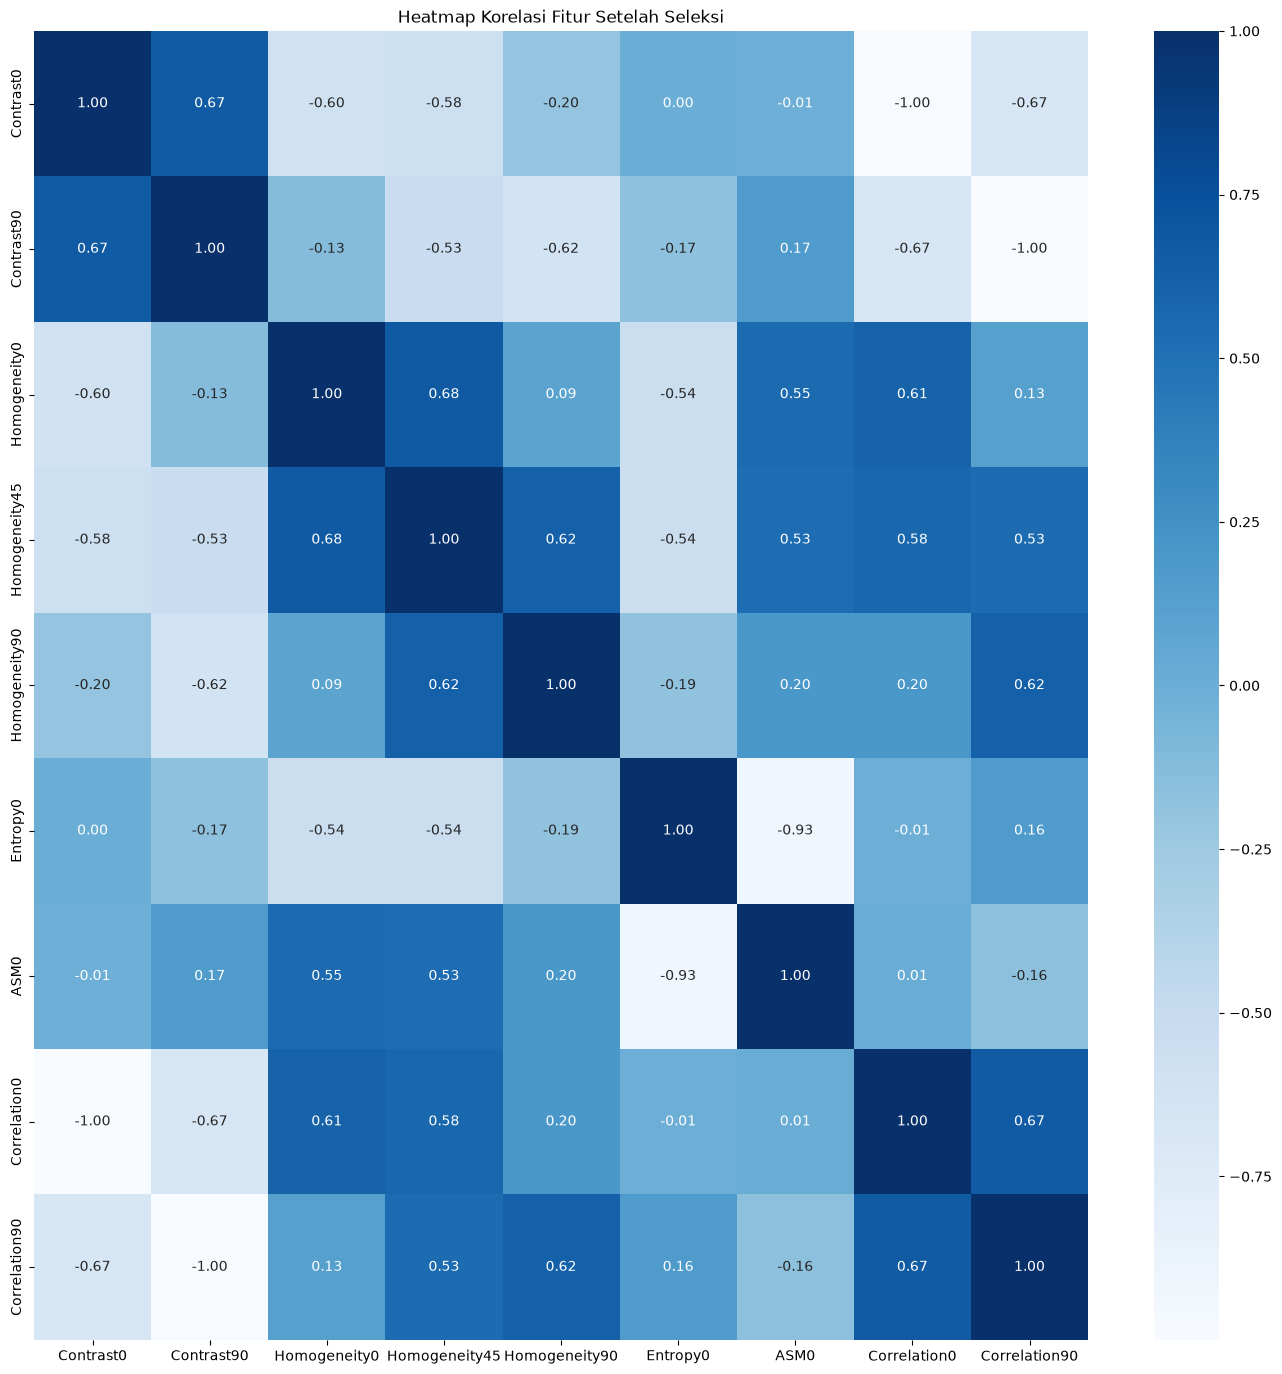

In [12]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.90
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {correlation.shape[0]}")
print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.show()

## Splitting Data

Dataset dibagi menjadi data pelatihan dan data pengujian menggunakan rasio tertentu.

Pembagian ini bertujuan untuk mengevaluasi kemampuan model dalam melakukan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

Salah satu keterbatasan metode hold-out adalah hasil evaluasi dapat dipengaruhi oleh pembagian data yang digunakan. Oleh karena itu, hasil akurasi sebaiknya dianalisis bersama confusion matrix dan metrik evaluasi lainnya.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1008, 9)
(252, 9)
(1008,)
(252,)


## Normalization

Normalisasi dilakukan untuk menyamakan skala antar fitur sebelum proses klasifikasi.

Langkah ini sangat penting terutama untuk algoritma berbasis jarak seperti KNN dan algoritma berbasis hyperplane seperti SVM. Tanpa normalisasi, fitur dengan rentang nilai terbesar dapat mendominasi proses pembelajaran model.

Pada penelitian ini normalisasi terbukti memberikan peningkatan performa yang signifikan terutama pada SVM dan KNN.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling

Tiga algoritma klasifikasi digunakan pada penelitian ini, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Random Forest dipilih karena kemampuannya menangani hubungan non-linear dan fitur dalam jumlah banyak. SVM dipilih karena dikenal memiliki performa baik pada data berdimensi tinggi. Sementara itu, KNN digunakan sebagai metode berbasis jarak yang sederhana namun efektif.

Penggunaan beberapa algoritma memungkinkan perbandingan performa sehingga dapat diketahui metode yang paling sesuai untuk karakteristik fitur tekstur yang dihasilkan.

In [15]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
svm = SVC(kernel='rbf', C=100, gamma='scale')
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

In [16]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.96      0.95      0.96        84
      Palapi       0.96      0.92      0.94        84
         Uru       0.92      0.98      0.95        84

    accuracy                           0.95       252
   macro avg       0.95      0.95      0.95       252
weighted avg       0.95      0.95      0.95       252

[[80  1  3]
 [ 3 77  4]
 [ 0  2 82]]
Accuracy: 0.9484126984126984


In [17]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       0.88      0.93      0.91       336
      Palapi       0.98      0.96      0.97       336
         Uru       0.91      0.88      0.89       336

    accuracy                           0.92      1008
   macro avg       0.92      0.92      0.92      1008
weighted avg       0.92      0.92      0.92      1008

[[313   0  23]
 [  6 322   8]
 [ 35   5 296]]
Accuracy: 0.9236111111111112

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.78      0.85      0.81        84
      Palapi       0.93      0.90      0.92        84
         Uru       0.78      0.74      0.76        84

    accuracy                           0.83       252
   macro avg       0.83      0.83      0.83       252
weighted avg       0.83      0.83      0.83       252

[[71  0 13]
 [ 4 76  4]
 [16  6 62]]
Accuracy: 0.8293650793650794


In [18]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.96      0.94      0.95        84
      Palapi       0.98      0.94      0.96        84
         Uru       0.92      0.98      0.95        84

    accuracy                           0.95       252
   macro avg       0.95      0.95      0.95       252
weighted avg       0.95      0.95      0.95       252

[[79  1  4]
 [ 2 79  3]
 [ 1  1 82]]
Accuracy: 0.9523809523809523


## Evaluation

Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

Accuracy digunakan untuk mengukur tingkat prediksi yang benar secara keseluruhan. Precision dan Recall digunakan untuk melihat performa pada masing-masing kelas, sedangkan Confusion Matrix digunakan untuk mengidentifikasi pola kesalahan klasifikasi yang terjadi.

Analisis confusion matrix sangat penting karena akurasi yang tinggi belum tentu menunjukkan bahwa seluruh kelas terklasifikasi dengan baik.

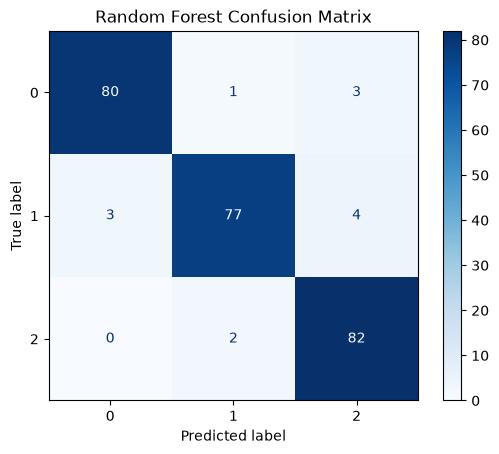

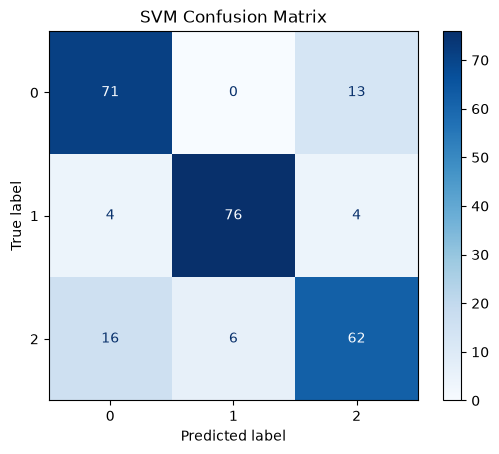

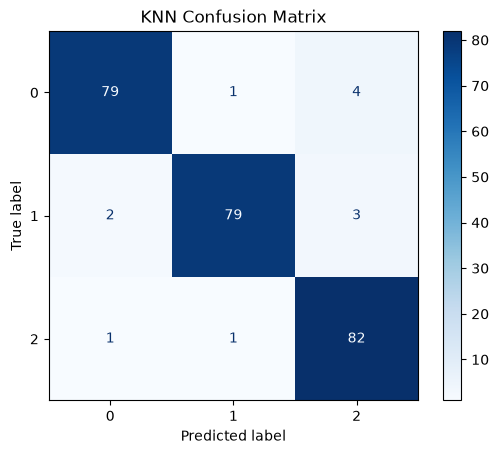

In [19]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Hasil Evaluasi Model

### Tabel Perbandingan Akurasi Training dan Testing Antar Percobaan

| Algoritma | Training P1 | Testing P1 | Training P2 | Testing P2 | Training P3 | Testing P3 |
|-----------|------------|------------|------------|------------|------------|------------|
| Random Forest | 98.41% | 76.19% | 100.00% | 94.05% | 100.00% | 94.84% |
| SVM | 62.70% | 47.62% | 81.94% | 76.19%| 92.36% | 82.93% |
| KNN | 84.13% | 60.32% | 100.00% | 92.46%| 100.00% | **95.24%** |

### Tabel Perbandingan Metrik Evaluasi pada Data Testing Percobaan 3

| Algoritma | Precision | Recall | F1-Score | Accuracy |
|-----------|----------|--------|----------|----------|
| Random Forest | 0.95 | 0.95 | 0.95 | 94.84% |
| SVM | 0.83 | 0.83 | 0.83 | 82.93% |
| KNN | **0.95** | **0.95** | **0.95** | **95.24%** |

---

## Analisis Hasil

Berdasarkan hasil evaluasi yang dilakukan pada tiga percobaan, dapat dilihat bahwa Percobaan 3 menghasilkan performa klasifikasi yang jauh lebih baik dibandingkan Percobaan 1 dan Percobaan 2. Peningkatan ini menunjukkan bahwa konfigurasi parameter dan proses pengolahan data yang digunakan pada Percobaan 3 mampu meningkatkan kemampuan model dalam mengenali pola tekstur citra kayu berdasarkan fitur GLCM.

Pada algoritma **Random Forest**, akurasi testing meningkat secara signifikan dari **76.19% pada Percobaan 1** dan **94.05% pada Percobaan 2** menjadi **94.84% pada Percobaan 3**. Selain itu, akurasi training mencapai **100%**, yang menunjukkan bahwa model mampu mempelajari karakteristik data dengan sangat baik. Peningkatan ini kemungkinan disebabkan oleh penggunaan jumlah pohon (estimators) yang lebih banyak sehingga model dapat menghasilkan keputusan yang lebih stabil dan akurat.

Pada algoritma **Support Vector Machine (SVM)**, terjadi peningkatan akurasi testing dari **47.62% pada Percobaan 1** dan **76.19% pada Percobaan 2** menjadi **82.93% pada Percobaan 3**. Walaupun mengalami peningkatan yang cukup besar, performa SVM masih lebih rendah dibandingkan Random Forest dan KNN. Hal ini mengindikasikan bahwa pemisahan antar kelas pada fitur tekstur yang digunakan belum sepenuhnya optimal jika dimodelkan menggunakan hyperplane SVM.

Algoritma **K-Nearest Neighbor (KNN)** menunjukkan peningkatan performa yang paling signifikan. Akurasi testing meningkat dari **60.32% pada Percobaan 1** dan **92.46% pada Percobaan 2** menjadi **95.24% pada Percobaan 3**. Selain itu, akurasi training mencapai **100%**, yang menunjukkan bahwa model mampu mengenali pola data dengan sangat baik. Penggunaan parameter yang lebih optimal pada Percobaan 3 membuat proses pencarian tetangga terdekat menjadi lebih efektif dalam membedakan tekstur kayu Nantu, Palapi, dan Uru.

Jika dibandingkan secara keseluruhan, **KNN pada Percobaan 3 menghasilkan akurasi testing tertinggi sebesar 95.24%**, diikuti oleh **Random Forest sebesar 94.84%**, sedangkan **SVM memperoleh akurasi sebesar 82.93%**. Selisih akurasi antara KNN dan Random Forest hanya sekitar **0.40%**, namun KNN tetap menjadi model dengan performa terbaik berdasarkan hasil pengujian.

---

## Kesimpulan

Berdasarkan hasil perbandingan ketiga percobaan, dapat disimpulkan bahwa **Percobaan 3 memberikan hasil klasifikasi terbaik dibandingkan Percobaan 1 dan Percobaan 2**. Dari seluruh model yang diuji, **K-Nearest Neighbor (KNN) pada Percobaan 3 merupakan model dengan akurasi tertinggi, yaitu sebesar 95.24%**, sehingga dapat direkomendasikan sebagai model terbaik untuk klasifikasi citra serat kayu Nantu, Palapi, dan Uru berdasarkan fitur tekstur GLCM. Random Forest menempati posisi kedua dengan akurasi 94.84%, sedangkan SVM memiliki performa paling rendah dengan akurasi 82.93%.